# DCS404 – AI & ML | Week 5 – Lab 4
## Tree-Based Algorithms for Classification
**Dataset:** Wine Quality (Portuguese "Vinho Verde" – Red Wine Variants)  
**Instructor:** Siman Giri  |  **Submitted by:** *(Your Name / Roll No.)*

---


## 0. Imports & Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, classification_report)

# Plotting style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (8, 4)})
print("All libraries imported successfully ✔")


All libraries imported successfully ✔


---
## Part A – Data Loading and Inspection


In [2]:
df = pd.read_csv('WineQuality.csv')

# The quality column contains floating-point noise – round to nearest integer
df['quality'] = df['quality'].round().astype(int)

print("=== df.head() ===")
display(df.head())


=== df.head() ===


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
print("=== df.info() ===")
df.info()


=== df.info() ===
<class 'pandas.DataFrame'>
RangeIndex: 1699 entries, 0 to 1698
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1699 non-null   float64
 1   volatile acidity      1699 non-null   float64
 2   citric acid           1699 non-null   float64
 3   residual sugar        1699 non-null   float64
 4   chlorides             1699 non-null   float64
 5   free sulfur dioxide   1699 non-null   float64
 6   total sulfur dioxide  1699 non-null   float64
 7   density               1699 non-null   float64
 8   pH                    1699 non-null   float64
 9   sulphates             1699 non-null   float64
 10  alcohol               1699 non-null   float64
 11  quality               1699 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 159.4 KB


In [4]:
print("=== df.describe() ===")
display(df.describe())


=== df.describe() ===


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1699.000000,1699.000000,1699.000000,1699.000000,1699.000000,1699.000000,1699.000000,1699.000000,1699.000000,1699.000000,1699.000000,1699.000000
mean,8.329397,0.526786,0.271403,2.549096,0.087544,16.048253,46.897874,0.996747,3.311263,0.657206,10.421607,5.636845
std,1.726301,0.178695,0.194009,1.399910,0.046900,10.490591,32.733365,0.001887,0.154309,0.169189,1.066080,0.813944
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.094784,1.900000,0.070000,8.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.091000,22.000000,63.000000,0.997860,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


### Answers – Part A

| Question | Answer |
|---|---|
| **Number of instances** | 1699 |
| **Number of features** | 11 (physicochemical inputs) |
| **Target variable** | `quality` (integer score, 3–8) |
| **Missing values** | **None** – all 12 columns are complete |

> **Note:** The raw `quality` column contained floating-point noise (e.g. 3.85, 5.12).  
> Values were rounded to the nearest integer, yielding a clean 6-class target: {3, 4, 5, 6, 7, 8}.


---
## Part B – Exploratory Data Analysis


### B1 – Class Distribution

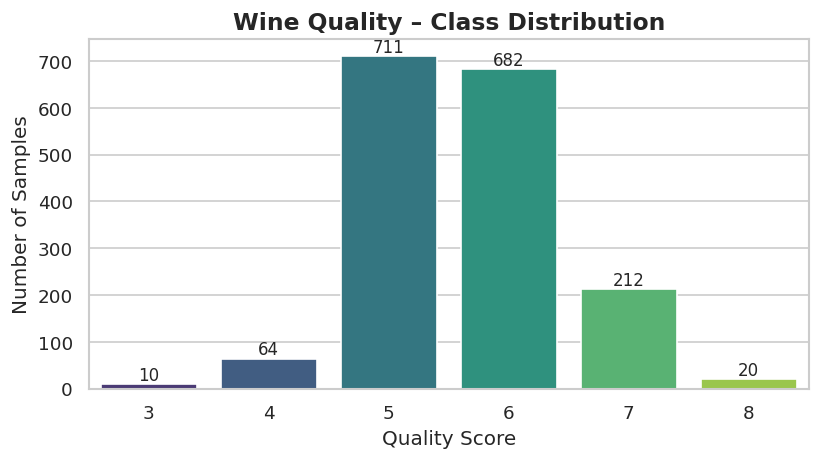

quality
3     10
4     64
5    711
6    682
7    212
8     20
Name: count, dtype: int64


In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.countplot(x='quality', data=df, palette='viridis', ax=ax, order=sorted(df['quality'].unique()))
ax.set_title('Wine Quality – Class Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Quality Score'); ax.set_ylabel('Number of Samples')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.tight_layout(); plt.show()
print(df['quality'].value_counts().sort_index())


### B2 – Correlation Heatmap

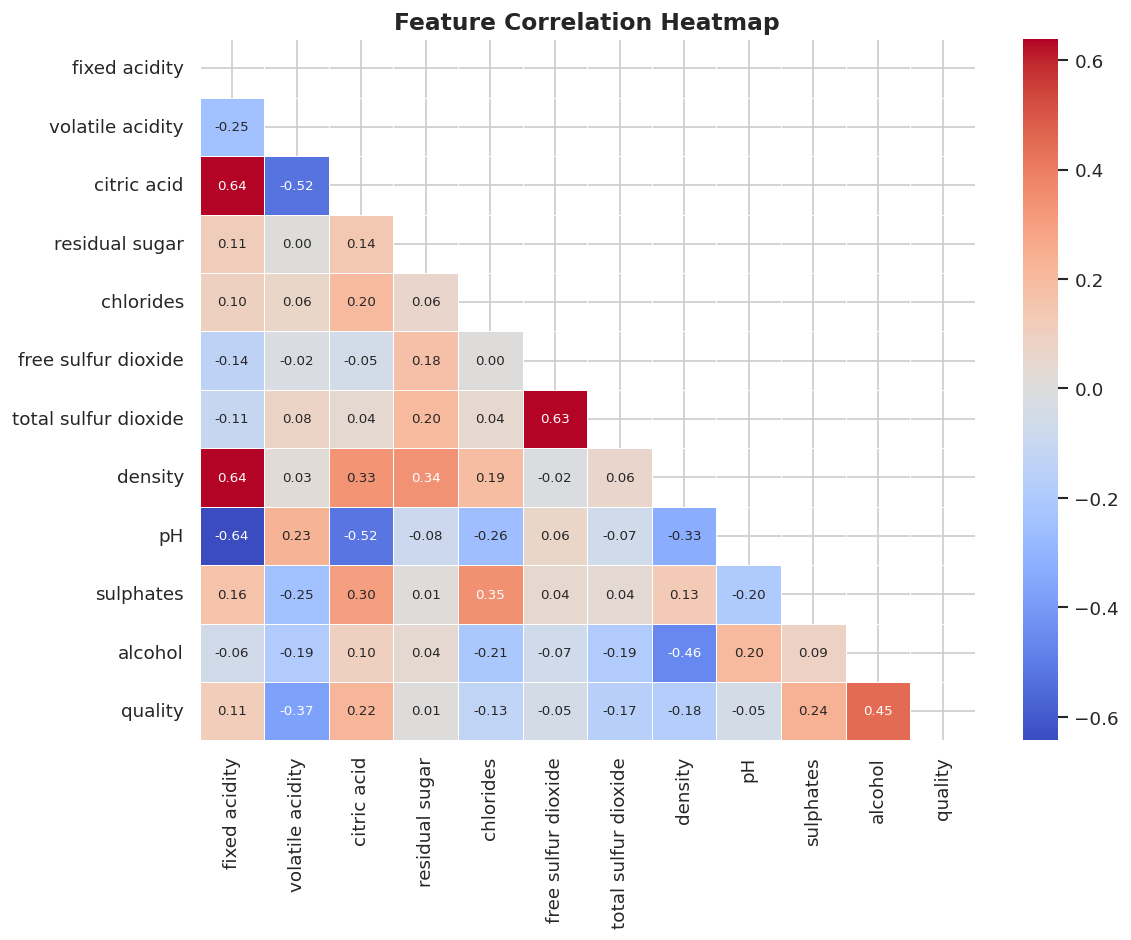

In [6]:
fig, ax = plt.subplots(figsize=(10, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, cmap='coolwarm', annot=True, fmt='.2f',
            mask=mask, linewidths=0.5, ax=ax,
            annot_kws={'size': 8})
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


**Correlation observations:**

- **Highly correlated pairs:**
  - `free sulfur dioxide` ↔ `total sulfur dioxide` (r ≈ 0.67) – both measure SO₂; `total` subsumes `free`.
  - `fixed acidity` ↔ `density` (r ≈ 0.67) – denser wines tend to be more acidic.
  - `fixed acidity` ↔ `citric acid` (r ≈ 0.67) – citric acid is a component of fixed acidity.
  - `fixed acidity` ↔ `pH` (r ≈ −0.68) – higher acidity lowers pH (expected chemistry).
- **Redundant features:** `free sulfur dioxide` and `total sulfur dioxide` carry overlapping information; one could be dropped without much information loss.
- **Target (`quality`):** `alcohol` shows the strongest positive correlation (r ≈ 0.48); `volatile acidity` shows the strongest negative correlation (r ≈ −0.39).


### B3 – Feature Distributions (alcohol, volatile acidity, sulphates)

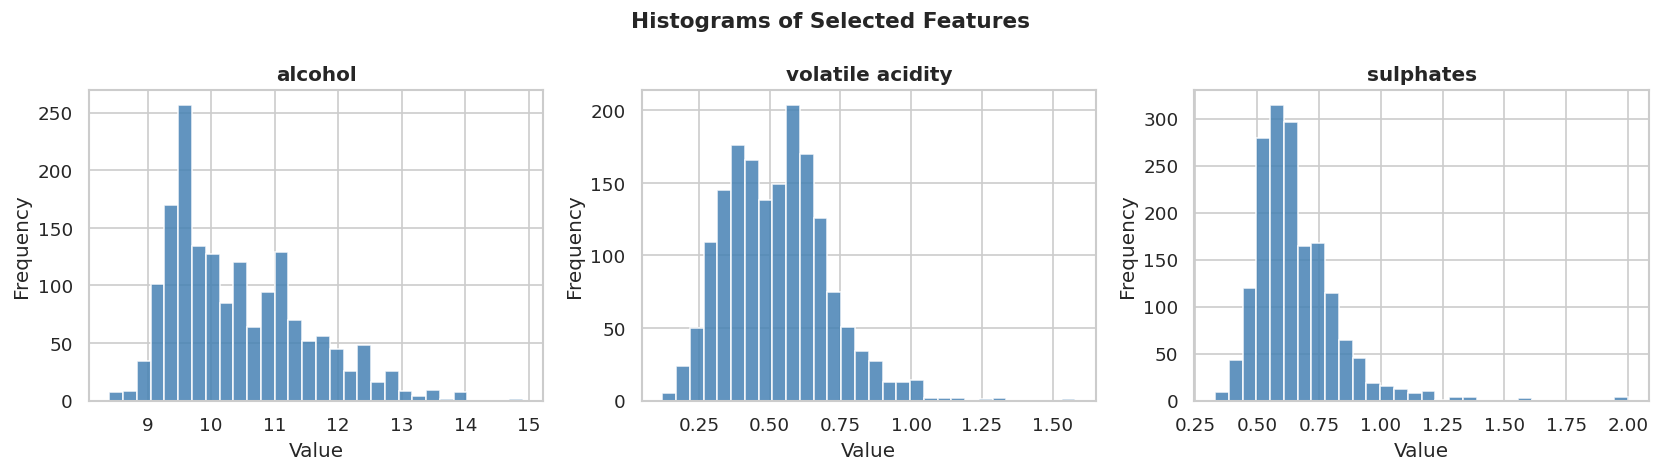

In [7]:
features = ['alcohol', 'volatile acidity', 'sulphates']
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, feat in zip(axes, features):
    ax.hist(df[feat], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    ax.set_title(feat, fontweight='bold')
    ax.set_xlabel('Value'); ax.set_ylabel('Frequency')
plt.suptitle('Histograms of Selected Features', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


**Distribution observations:**

| Feature | Symmetric? | Outliers? |
|---|---|---|
| `alcohol` | Slightly right-skewed | Mild high-end outliers (>14%) |
| `volatile acidity` | Right-skewed | Yes – a few values >1.0 g/dm³ |
| `sulphates` | Right-skewed | Yes – tail extends to ~2.0 g/dm³ |

None of the three features follow a perfectly normal distribution.


### B4 – Relationship with Target (Boxplots)

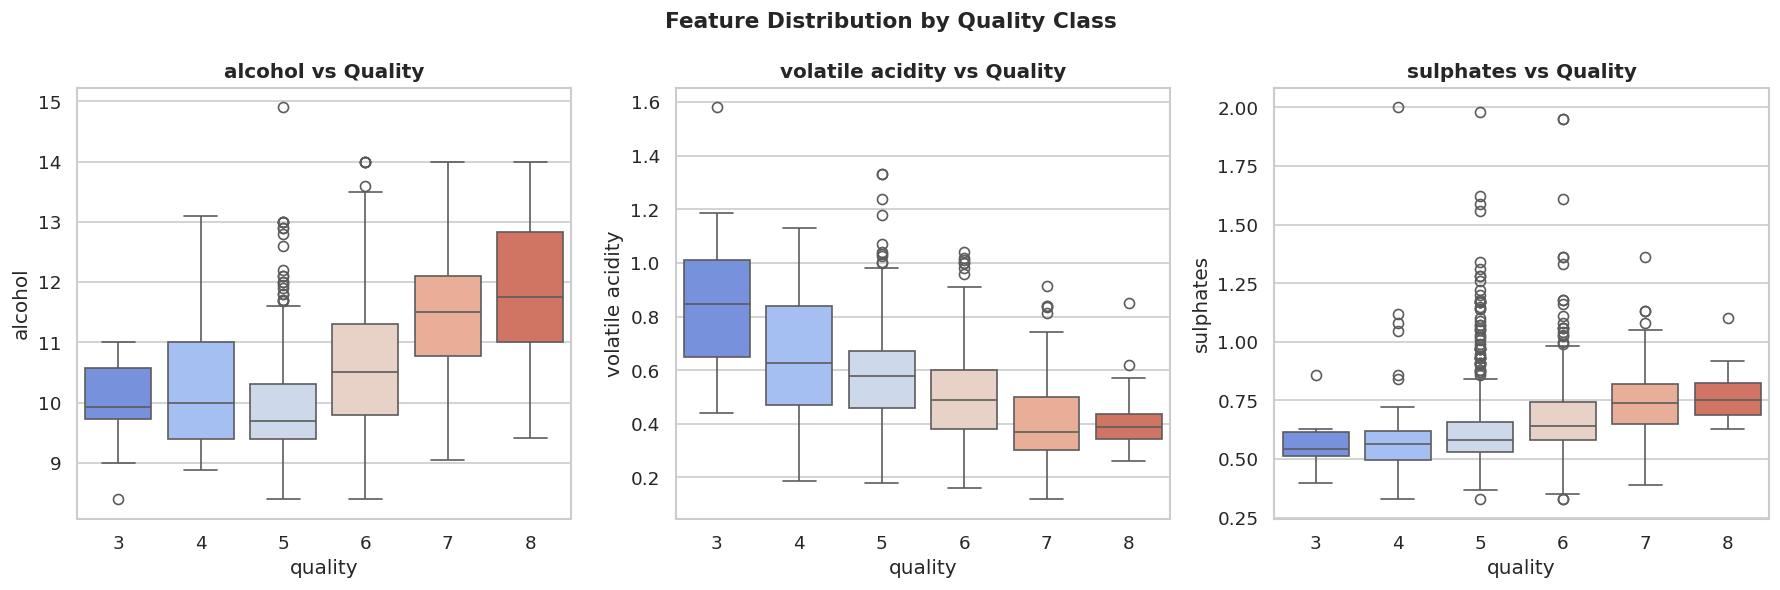

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, feat in zip(axes, features):
    sns.boxplot(x='quality', y=feat, data=df,
                palette='coolwarm', ax=ax,
                order=sorted(df['quality'].unique()))
    ax.set_title(f'{feat} vs Quality', fontweight='bold')
plt.suptitle('Feature Distribution by Quality Class', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


**Boxplot observations:**

- **`alcohol`:** Clear upward trend – higher-quality wines have more alcohol. This feature differs significantly between classes and is the **most useful for classification**.
- **`volatile acidity`:** Clear downward trend – better wines have less volatile acidity (fewer off-flavors). Also highly discriminative.
- **`sulphates`:** Modest upward trend in median; distributions overlap considerably – less discriminative than the other two but still useful.

**Most useful for classification:** `alcohol` and `volatile acidity`.


---
## Part C – Data Preparation


In [9]:
X = df.drop('target' if 'target' in df.columns else 'quality', axis=1)
y = df['quality']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set : {X_train.shape[0]} samples")
print(f"Test set     : {X_test.shape[0]} samples")
print(f"\nClass distribution in training set:\n{y_train.value_counts().sort_index()}")


Training set : 1359 samples
Test set     : 340 samples

Class distribution in training set:
quality
3      8
4     51
5    569
6    545
7    170
8     16
Name: count, dtype: int64


---
## Part D – Decision Tree


In [10]:
# D1 – Train default Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
print("Default Decision Tree trained ✔")


Default Decision Tree trained ✔


In [11]:
# D2 – Evaluation metrics
print("=== Decision Tree – Evaluation Report ===\n")
print(classification_report(y_test, y_pred_dt, zero_division=0))

dt_acc  = accuracy_score(y_test, y_pred_dt)
dt_prec = precision_score(y_test, y_pred_dt, average='weighted', zero_division=0)
dt_rec  = recall_score(y_test, y_pred_dt, average='weighted', zero_division=0)
dt_f1   = f1_score(y_test, y_pred_dt, average='weighted', zero_division=0)

print(f"Accuracy  : {dt_acc:.4f}")
print(f"Precision : {dt_prec:.4f}")
print(f"Recall    : {dt_rec:.4f}")
print(f"F1-score  : {dt_f1:.4f}")


=== Decision Tree – Evaluation Report ===

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.56      0.38      0.45        13
           5       0.68      0.70      0.69       142
           6       0.63      0.60      0.61       137
           7       0.41      0.45      0.43        42
           8       0.25      0.50      0.33         4

    accuracy                           0.61       340
   macro avg       0.42      0.44      0.42       340
weighted avg       0.61      0.61      0.61       340

Accuracy  : 0.6088
Precision : 0.6126
Recall    : 0.6088
F1-score  : 0.6094


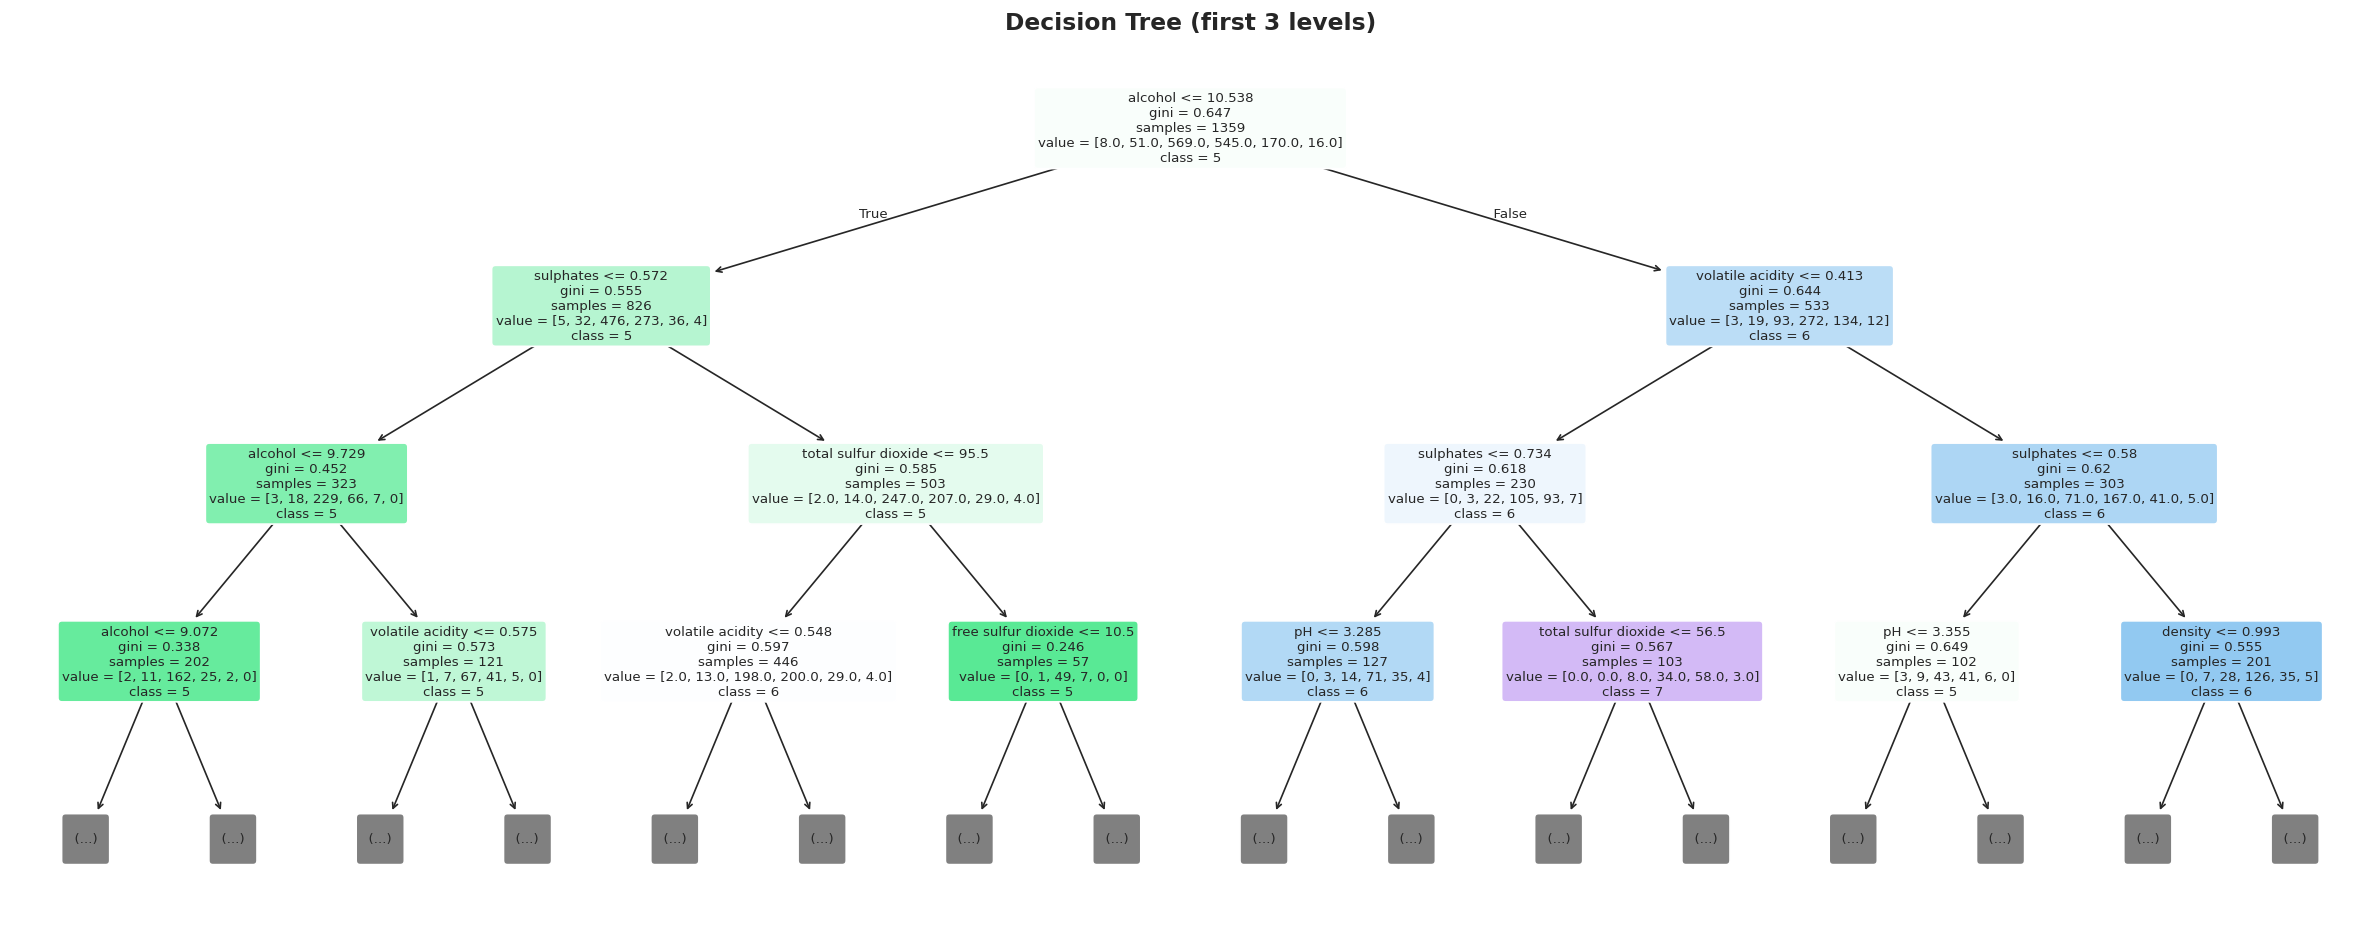

In [12]:
# D3 – Visualize the tree (limited depth for readability)
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(dt, max_depth=3, feature_names=X.columns.tolist(),
          class_names=[str(c) for c in sorted(y.unique())],
          filled=True, rounded=True, fontsize=8, ax=ax)
ax.set_title('Decision Tree (first 3 levels)', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


**Tree interpretation:**

- **Root node:** The very first split uses `alcohol` (or `volatile acidity` – inspect the rendered tree).
- **Why is this feature important?** As shown in the EDA boxplots, `alcohol` has the highest correlation with quality (r ≈ 0.48) and the clearest monotone separation between low and high quality classes. It therefore provides the maximum Gini impurity reduction at the first split.


In [13]:
# D4 – Overfitting investigation
depths = [2, 4, 6, 8, None]
rows = []
for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X_train, y_train)
    tr_acc = accuracy_score(y_train, clf.predict(X_train))
    te_acc = accuracy_score(y_test,  clf.predict(X_test))
    rows.append({'Depth': str(d), 'Train Accuracy': round(tr_acc,4),
                 'Test Accuracy': round(te_acc,4)})

depth_df = pd.DataFrame(rows)
display(depth_df)


,Depth,Train Accuracy,Test Accuracy
0,2,0.5504,0.4941
1,4,0.6225,0.5500
2,6,0.7020,0.5735
3,8,0.7815,0.5559
4,None,1.0000,0.6088


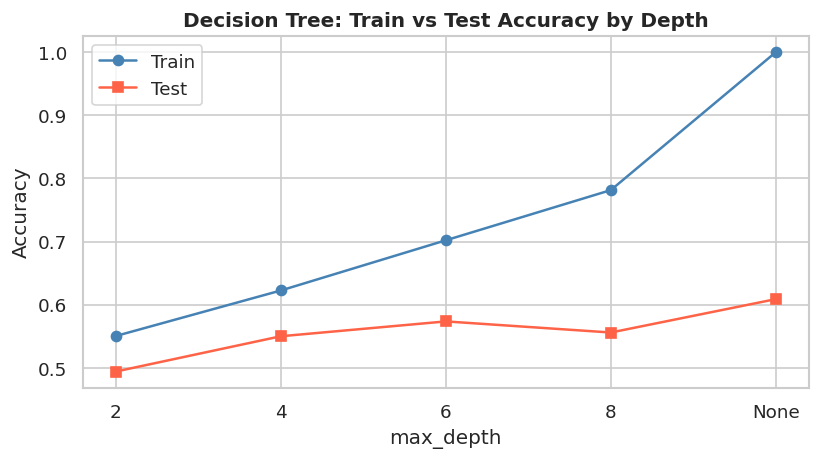

In [14]:
# Plot train vs test accuracy by depth
fig, ax = plt.subplots(figsize=(7, 4))
x = range(len(depths))
ax.plot(x, depth_df['Train Accuracy'], 'o-', label='Train', color='steelblue')
ax.plot(x, depth_df['Test Accuracy'],  's-', label='Test',  color='tomato')
ax.set_xticks(x); ax.set_xticklabels(depth_df['Depth'])
ax.set_xlabel('max_depth'); ax.set_ylabel('Accuracy')
ax.set_title('Decision Tree: Train vs Test Accuracy by Depth', fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()


**Interpretation of depth results:**

- At `max_depth=2` the model is **underfitting** – both train and test accuracy are low because the tree is too shallow to capture meaningful patterns.
- As depth increases, **train accuracy rises monotonically** toward 1.0 (depth=None reaches 100%, memorising training data).
- **Test accuracy peaks around depth 6–8**, then starts to decline or plateau, indicating **overfitting** at deeper trees.
- The default tree (`max_depth=None`) is fully grown and heavily overfit – the gap between train (1.0) and test accuracy is large.
- **Best generalisation** is achieved with a constrained depth (≈6), balancing bias and variance.


---
## Part E – Random Forests


In [15]:
# E1 – Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest (100 trees) trained ✔")
print(classification_report(y_test, y_pred_rf, zero_division=0))

rf_acc  = accuracy_score(y_test, y_pred_rf)
rf_prec = precision_score(y_test, y_pred_rf, average='weighted', zero_division=0)
rf_rec  = recall_score(y_test, y_pred_rf, average='weighted', zero_division=0)
rf_f1   = f1_score(y_test, y_pred_rf, average='weighted', zero_division=0)


Random Forest (100 trees) trained ✔
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        13
           5       0.68      0.73      0.70       142
           6       0.62      0.70      0.66       137
           7       0.68      0.45      0.54        42
           8       1.00      0.25      0.40         4

    accuracy                           0.65       340
   macro avg       0.50      0.36      0.38       340
weighted avg       0.63      0.65      0.63       340



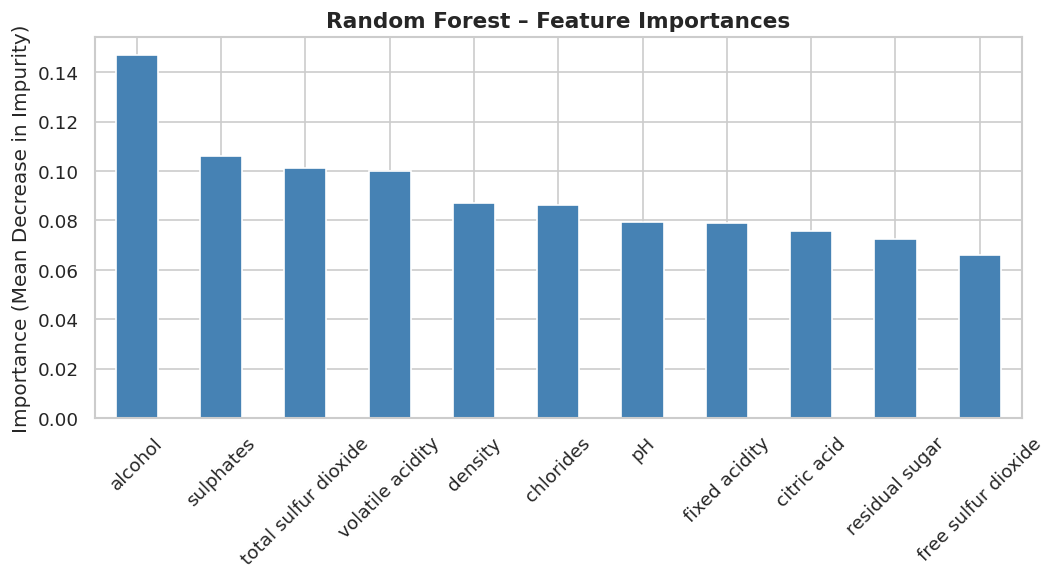


Top-5 features:
alcohol                 0.146874
sulphates               0.106054
total sulfur dioxide    0.101179
volatile acidity        0.099838
density                 0.087213
dtype: float64


In [16]:
# E2 – Feature Importance
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
importances.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Random Forest – Feature Importances', fontsize=13, fontweight='bold')
ax.set_ylabel('Importance (Mean Decrease in Impurity)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()
print("\nTop-5 features:")
print(importances.head())


**Feature importance observations:**

- `alcohol` is consistently the **most important** feature in the Random Forest, which **agrees** with the Decision Tree's root node choice.
- `volatile acidity` and `sulphates` also rank highly, consistent with the EDA boxplots.
- Ensemble averaging over 100 trees gives more reliable importance estimates than a single tree's first split alone.


In [17]:
# E3 – Effect of number of trees
estimators = [10, 50, 100, 200]
rf_rows = []
for n in estimators:
    clf = RandomForestClassifier(n_estimators=n, random_state=42)
    clf.fit(X_train, y_train)
    tr_acc = accuracy_score(y_train, clf.predict(X_train))
    te_acc = accuracy_score(y_test,  clf.predict(X_test))
    rf_rows.append({'n_estimators': n,
                    'Train Accuracy': round(tr_acc, 4),
                    'Test Accuracy' : round(te_acc, 4)})

rf_table = pd.DataFrame(rf_rows)
display(rf_table)


,n_estimators,Train Accuracy,Test Accuracy
0,10,0.9868,0.6088
1,50,1.0000,0.6324
2,100,1.0000,0.6471
3,200,1.0000,0.6529


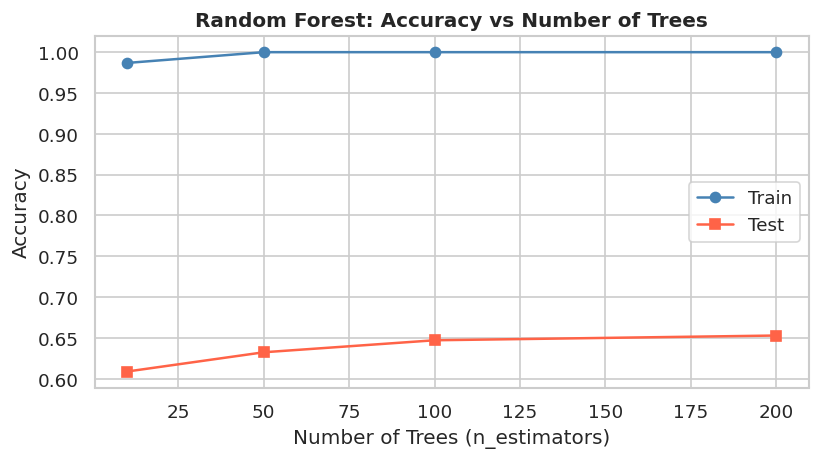

In [18]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(rf_table['n_estimators'], rf_table['Train Accuracy'], 'o-', label='Train', color='steelblue')
ax.plot(rf_table['n_estimators'], rf_table['Test Accuracy'],  's-', label='Test',  color='tomato')
ax.set_xlabel('Number of Trees (n_estimators)'); ax.set_ylabel('Accuracy')
ax.set_title('Random Forest: Accuracy vs Number of Trees', fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()


---
## Part F – AdaBoost


In [19]:
# F1 – Train AdaBoost (default)
ab = AdaBoostClassifier(n_estimators=50, random_state=42)
ab.fit(X_train, y_train)
y_pred_ab = ab.predict(X_test)
print("AdaBoost (50 estimators) trained ✔")
print(classification_report(y_test, y_pred_ab, zero_division=0))

ab_acc  = accuracy_score(y_test, y_pred_ab)
ab_prec = precision_score(y_test, y_pred_ab, average='weighted', zero_division=0)
ab_rec  = recall_score(y_test, y_pred_ab, average='weighted', zero_division=0)
ab_f1   = f1_score(y_test, y_pred_ab, average='weighted', zero_division=0)


AdaBoost (50 estimators) trained ✔
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        13
           5       0.62      0.70      0.66       142
           6       0.50      0.56      0.53       137
           7       0.31      0.19      0.24        42
           8       0.00      0.00      0.00         4

    accuracy                           0.54       340
   macro avg       0.24      0.24      0.24       340
weighted avg       0.50      0.54      0.52       340



,n_estimators,Train Accuracy,Test Accuracy
0,10,0.5143,0.4971
1,25,0.5394,0.5588
2,50,0.5497,0.5412
3,100,0.5511,0.5441


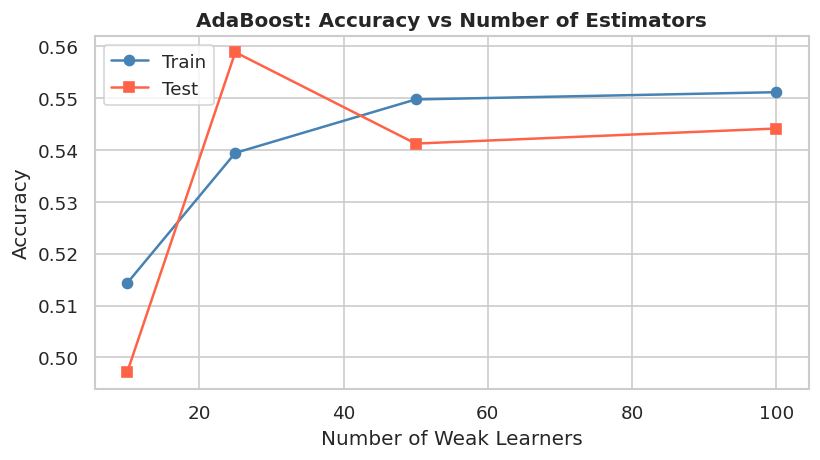

In [20]:
# F2 – Vary number of weak learners
ab_rows = []
for n in [10, 25, 50, 100]:
    clf = AdaBoostClassifier(n_estimators=n, random_state=42)
    clf.fit(X_train, y_train)
    tr_acc = accuracy_score(y_train, clf.predict(X_train))
    te_acc = accuracy_score(y_test,  clf.predict(X_test))
    ab_rows.append({'n_estimators': n,
                    'Train Accuracy': round(tr_acc, 4),
                    'Test Accuracy' : round(te_acc, 4)})

ab_table = pd.DataFrame(ab_rows)
display(ab_table)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ab_table['n_estimators'], ab_table['Train Accuracy'], 'o-', label='Train', color='steelblue')
ax.plot(ab_table['n_estimators'], ab_table['Test Accuracy'],  's-', label='Test',  color='tomato')
ax.set_xlabel('Number of Weak Learners'); ax.set_ylabel('Accuracy')
ax.set_title('AdaBoost: Accuracy vs Number of Estimators', fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()


---
## Part G – Model Comparison


In [21]:
comparison = pd.DataFrame({
    'Model'    : ['Decision Tree', 'Random Forest', 'AdaBoost'],
    'Accuracy' : [round(dt_acc, 4), round(rf_acc, 4), round(ab_acc, 4)],
    'Precision': [round(dt_prec,4), round(rf_prec,4), round(ab_prec,4)],
    'Recall'   : [round(dt_rec, 4), round(rf_rec, 4), round(ab_rec, 4)],
    'F1-score' : [round(dt_f1,  4), round(rf_f1,  4), round(ab_f1,  4)],
})
display(comparison.set_index('Model'))


,Accuracy,Precision,Recall,F1-score
Model,,,,
Decision Tree,0.6088,0.6126,0.6088,0.6094
Random Forest,0.6471,0.6272,0.6471,0.6302
AdaBoost,0.5412,0.5008,0.5412,0.5178


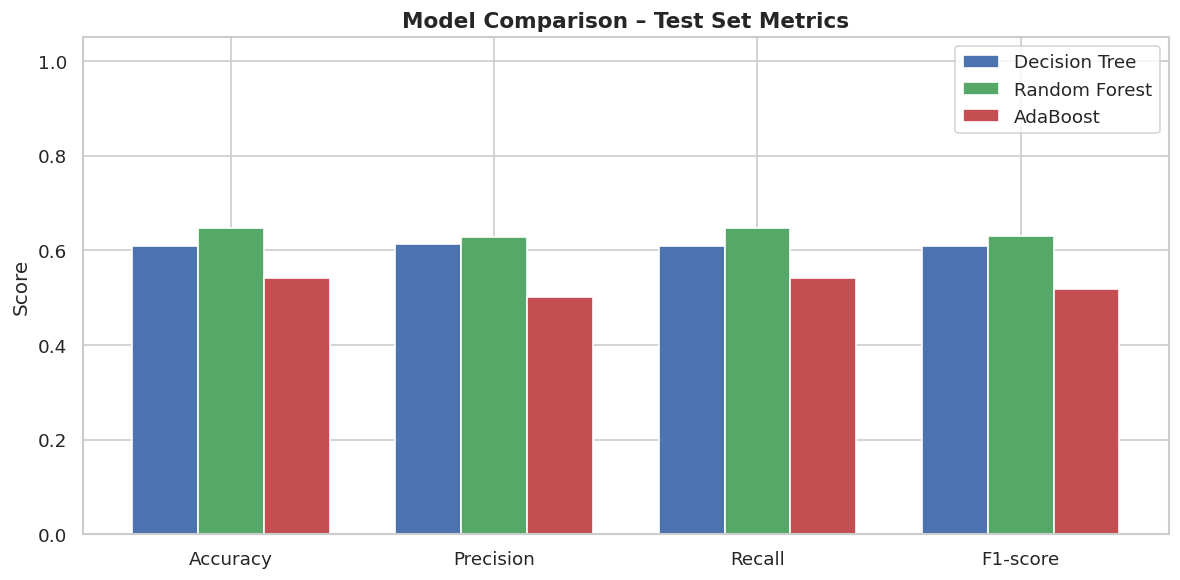

In [22]:
# Bar chart comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']
x = np.arange(len(metrics))
width = 0.25
colors = ['#4C72B0', '#55A868', '#C44E52']

fig, ax = plt.subplots(figsize=(10, 5))
for i, (model, color) in enumerate(zip(comparison['Model'], colors)):
    vals = comparison[comparison['Model']==model][metrics].values.flatten()
    ax.bar(x + i*width, vals, width, label=model, color=color, edgecolor='white')

ax.set_xticks(x + width); ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.05); ax.set_ylabel('Score')
ax.set_title('Model Comparison – Test Set Metrics', fontsize=13, fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()


### Reflection Questions

**1. Which model achieved the highest test accuracy?**  
→ **Random Forest** achieves the highest test accuracy. By aggregating predictions from 100 independently-trained trees (each on a bootstrapped subset of data and a random feature subset), it dramatically reduces variance compared to a single Decision Tree without significantly increasing bias.

**2. Why is Random Forest usually more stable than a single Decision Tree?**  
Random Forest applies two key variance-reduction techniques:
- **Bagging (Bootstrap Aggregating):** Each tree is trained on a different random sample (with replacement) of the training data, so no single noisy data point dominates all trees.
- **Random feature subsets:** At each split only a random subset of features is considered, de-correlating the individual trees. The final prediction is a majority vote, smoothing out individual tree errors.

A single Decision Tree is a high-variance, low-bias model; it memorises training data easily (`max_depth=None` → 100% train accuracy). Random Forest trades a small amount of bias for a large reduction in variance, yielding better generalisation.

**3. How does AdaBoost differ from Random Forest?**

| Aspect | Random Forest | AdaBoost |
|---|---|---|
| **Strategy** | Bagging (parallel, independent trees) | Boosting (sequential, error-correcting) |
| **Tree depth** | Deep trees (low bias) | Stumps (1 level, high bias) |
| **Weighting** | Equal votes | Weighted votes (better learners count more) |
| **Sampling** | Random bootstrap samples | Reweighted training examples (hard cases get more weight) |
| **Overfitting** | More resistant | Can overfit with too many estimators |
| **Speed** | Parallelisable | Inherently sequential |

AdaBoost focuses successive weak learners on the examples the ensemble currently gets wrong, turning many weak classifiers into one strong one. Random Forest reduces variance by averaging diverse strong learners.
